In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import sys
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path
import random

In [3]:
from analysis.utils import load_sweep_metadata, load_data, compute_success

In [4]:
# Example usage:
df_metadata = load_sweep_metadata(
    sweep_base_dirs=
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-15-cartpole_swingup-noncentered-initial_conditions_seeds_sweep",
    json_file_name="episode_metadata.json")


Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-15-cartpole_swingup-noncentered-initial_conditions_seeds_sweep: 100%|██████████| 275/275 [00:00<00:00, 277.61it/s]

Found 275 configurations


In [5]:
df = load_data(
    df_metadata,
    #cart_position=0.,
    episode_file_name="episode_data.pkl")

Found 275 configurations


  0%|          | 0/275 [00:00<?, ?it/s]

100%|██████████| 275/275 [00:02<00:00, 133.78it/s]


In [6]:
obs = np.concatenate(df['observations'].tolist())
actions = np.concatenate(df['actions'].tolist())
z = np.concatenate(df['latent_states'].tolist())
z.shape, obs.shape, actions.shape

((137500, 512), (137500, 5), (137500, 1))

In [14]:
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

random.seed(0)

# Train-test split
X_test = z[:5500]
X_train = z[5500:]

# Dictionary to store results for both targets
results_dict = {}

# Train for actions
y_test_actions = actions[:5500]
y_train_actions = actions[5500:]

lr_actions = LinearRegression()
lr_actions.fit(X_train, y_train_actions)
y_pred_actions = lr_actions.predict(X_test)
r2_actions = r2_score(y_test_actions, y_pred_actions)
print(f"Linear Regression R2 Score (Actions): {r2_actions}")

results_dict['actions'] = {
    'coef': lr_actions.coef_,
    'intercept': lr_actions.intercept_,
    'r2': r2_actions
}

# Train for observations
y_test_obs = obs[:5500]
y_train_obs = obs[5500:]

lr_obs = LinearRegression()
lr_obs.fit(X_train, y_train_obs)
y_pred_obs = lr_obs.predict(X_test)
r2_obs = r2_score(y_test_obs, y_pred_obs)
print(f"Linear Regression R2 Score (Observations): {r2_obs}")

results_dict['position'] = {
    'coef': lr_obs.coef_[0, :],
    'intercept': lr_obs.intercept_,
    'r2': r2_obs
}

n_random = 3

for i in range(n_random):
    results_dict[f'random_{i}'] = {
        'coef': np.random.randn(z.shape[1]) * 0.3,
        'intercept': 0,
        'r2': 0
    }

Linear Regression R2 Score (Actions): 0.7484629154205322
Linear Regression R2 Score (Observations): 0.9973715543746948


In [15]:
results_dict.keys()

dict_keys(['actions', 'position', 'random_0', 'random_1', 'random_2'])

<StemContainer object of 3 artists>

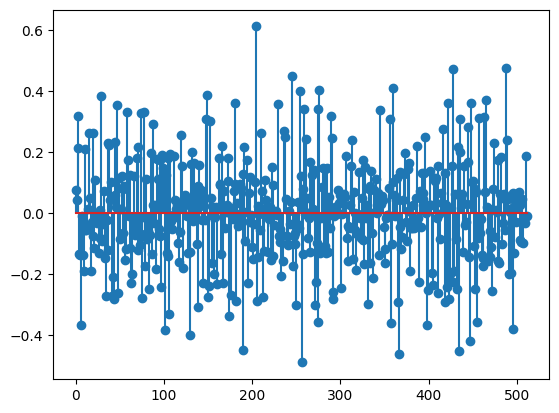

In [17]:
plt.stem(results_dict['position']['coef'])

In [18]:
# Save coefficients to file
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/25-12-15-control-position-cartpole-swingup-noncentered/w_lr_coefs_noncentered.pkl',
        'wb') as f:
    pickle.dump(results_dict, f)

print("Coefficients saved to linear_regression_coefficients.pkl")


Coefficients saved to linear_regression_coefficients.pkl


In [37]:
# Load coefficients from file
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/25-12-15-control-position-cartpole-swingup-noncentered/w_lr_coefs_noncentered.pkl',
        'rb') as f:
    results_dict = pickle.load(f)

print("Coefficients loaded from linear_regression_coefficients.pkl")

Coefficients loaded from linear_regression_coefficients.pkl


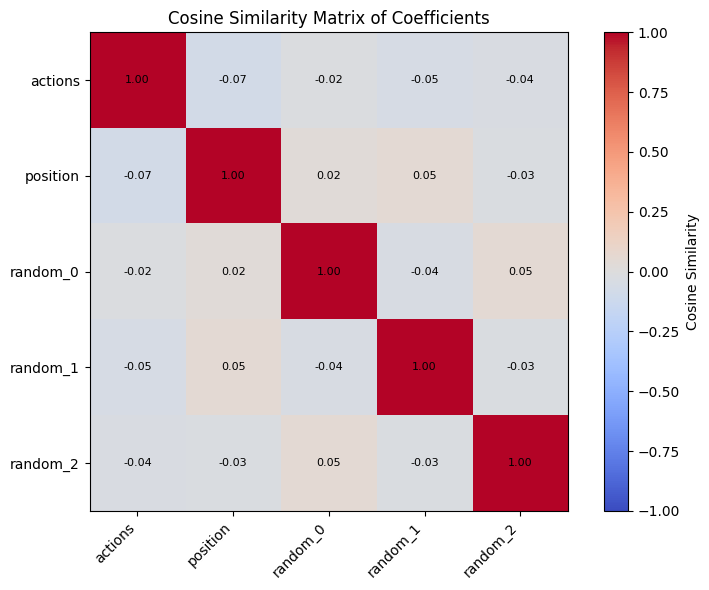

In [39]:
# Compute cosine similarity matrix
from sklearn.metrics.pairwise import cosine_similarity

# Extract all coefficient vectors
keys = list(results_dict.keys())
coef_matrix = np.array([results_dict[key]['coef'].squeeze() for key in keys])

# Compute cosine similarity
cos_sim_matrix = cosine_similarity(coef_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cos_sim_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(keys)), keys, rotation=45, ha='right')
plt.yticks(range(len(keys)), keys)
plt.title('Cosine Similarity Matrix of Coefficients')

# Add text annotations
for i in range(len(keys)):
    for j in range(len(keys)):
        text = plt.text(j,
                        i,
                        f'{cos_sim_matrix[i, j]:.2f}',
                        ha="center",
                        va="center",
                        color="black",
                        fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from typing import List, Dict, Any
from tqdm import tqdm


def lagged_and_delta_probes(
    Z: np.ndarray,  # (N, d) activations
    O: np.ndarray,  # (N, 5) observations
    ks: List[int] = [0, 1, 2, 3, 5, 10],
    n_shuffle: int = 5,  # shuffle baseline repeats
    random_state: int = 0,
) -> Dict[str, Dict[str, Any]]:
    """
    Runs:
      - Z_t -> x_{t+k}
      - Z_t -> Δ_k x_t
    plus baselines:
      - shuffled target
      - autocorrelation baseline

    Returns:
      results[probe_name] = {
          'r2': float,
          'shuffle_r2': float,
          'autocorr_r2': float
      }
    """
    rng = np.random.RandomState(random_state)

    assert Z.ndim == 2
    assert O.ndim == 2
    assert Z.shape[0] == O.shape[0]

    x = O[:, 0]  # cart position
    N = len(x)

    results = {}

    def fit_lr(Z_, y_, return_coef=False):
        model = LinearRegression(fit_intercept=True)
        model.fit(Z_, y_)
        y_pred = model.predict(Z_)
        if return_coef:
            return model.coef_, r2_score(y_, y_pred)
        else:
            return r2_score(y_, y_pred)

    def shuffle_baseline(Z_, y_):
        r2s = []
        for _ in range(n_shuffle):
            y_shuf = rng.permutation(y_)
            r2_score = fit_lr(Z_, y_shuf)
            r2s.append(r2_score)
        return float(np.mean(r2s)) if r2s else np.nan

    # -----------------------
    # Lagged probes: x_{t+k}
    # -----------------------
    for k in tqdm(ks, desc="Lagged probes"):
        if k >= N:
            continue

        Zk = Z[:N - k]
        yk = x[k:]

        coef, r2 = fit_lr(Zk, yk, return_coef=True)
        shuf = shuffle_baseline(Zk, yk)

        # autocorr baseline: x_t -> x_{t+k}
        if k == 0:
            autocorr = 1.0
        else:
            autocorr = r2_score(x[k:], x[:-k])

        results[f"x_t+{k}"] = {
            "coef": coef,
            "r2": float(r2),
            "shuffle_r2": float(shuf),
            "autocorr_r2": float(autocorr),
        }

    # -----------------------
    # Delta probes: Δ_k x_t
    # -----------------------
    for k in tqdm(ks, desc="Delta probes"):
        if k == 0 or k >= N:
            continue

        Zk = Z[:N - k]
        yk = x[k:] - x[:N - k]  # Δ_k

        coef_delta, r2_delta = fit_lr(Zk, yk, return_coef=True)
        shuf = shuffle_baseline(Zk, yk)

        # autocorr baseline for Δ_k
        if k + 1 < N:
            #autocorr = r2_score(x[k + 1:] - x[1:-k + 1], x[k:] - x[:-k])
            autocorr = 0.
        else:
            autocorr = np.nan

        results[f"delta_{k}"] = {
            "coef": coef_delta,
            "r2": float(r2_delta),
            "shuffle_r2": float(shuf),
            "autocorr_r2": float(autocorr),
        }

    return results


In [42]:
results = lagged_and_delta_probes(z,
                                  obs,
                                  ks=[0, 10, 20, 30, 40, 50],
                                  n_shuffle=0)

for k, v in results.items():
    print(f"{k:10s} | "
          f"R²={v['r2']:+.3f} | "
          f"shuffle={v['shuffle_r2']:+.3f} | "
          f"autocorr={v['autocorr_r2']:+.3f}")


  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:17<00:00,  2.91s/it]


x_t+0      | R²=+0.998 | shuffle=+nan | autocorr=+1.000
x_t+10     | R²=+0.916 | shuffle=+nan | autocorr=+0.872
x_t+20     | R²=+0.845 | shuffle=+nan | autocorr=+0.688
x_t+30     | R²=+0.784 | shuffle=+nan | autocorr=+0.493
x_t+40     | R²=+0.724 | shuffle=+nan | autocorr=+0.318
x_t+50     | R²=+0.656 | shuffle=+nan | autocorr=+0.176
delta_10   | R²=+0.354 | shuffle=+nan | autocorr=+0.000
delta_20   | R²=+0.502 | shuffle=+nan | autocorr=+0.000
delta_30   | R²=+0.572 | shuffle=+nan | autocorr=+0.000
delta_40   | R²=+0.592 | shuffle=+nan | autocorr=+0.000
delta_50   | R²=+0.580 | shuffle=+nan | autocorr=+0.000


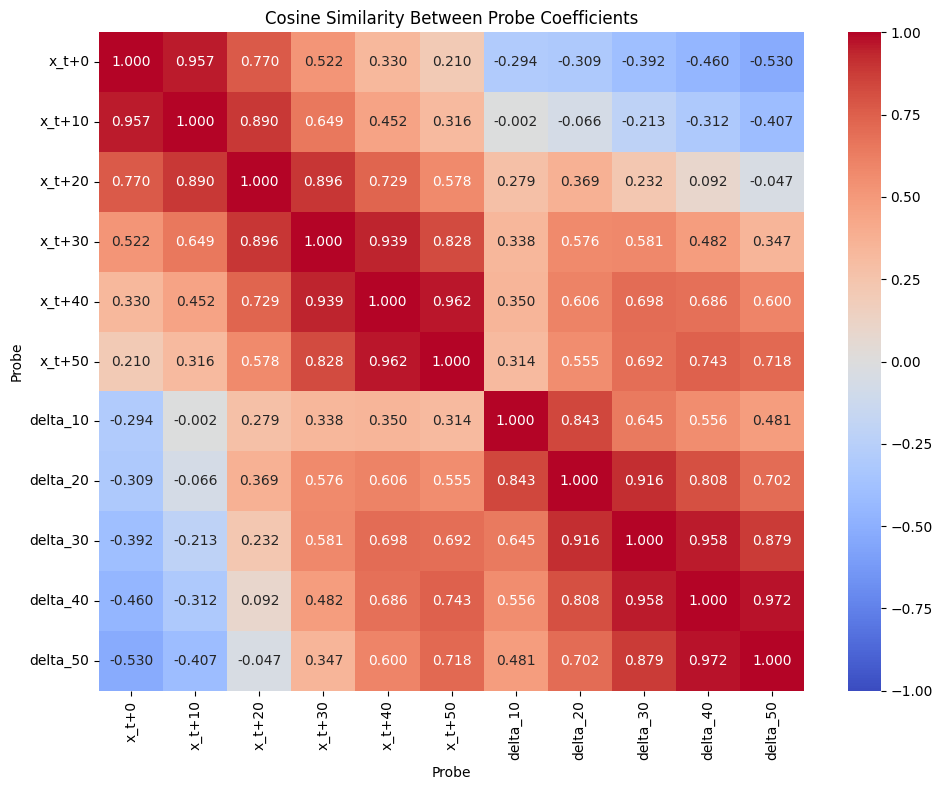

In [43]:
# Compute cosine similarity between coefficients
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Extract coefficients from results
coef_dict = {}
for k, v in results.items():
    if 'coef' in v:
        coef_dict[k] = v['coef']

# Create matrix of coefficients
keys = list(coef_dict.keys())
coef_matrix = np.array([coef_dict[k] for k in keys])

# Compute cosine similarity
similarity_matrix = cosine_similarity(coef_matrix)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix,
            annot=True,
            fmt='.3f',
            xticklabels=keys,
            yticklabels=keys,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0)
plt.title('Cosine Similarity Between Probe Coefficients')
plt.xlabel('Probe')
plt.ylabel('Probe')
plt.tight_layout()
plt.show()

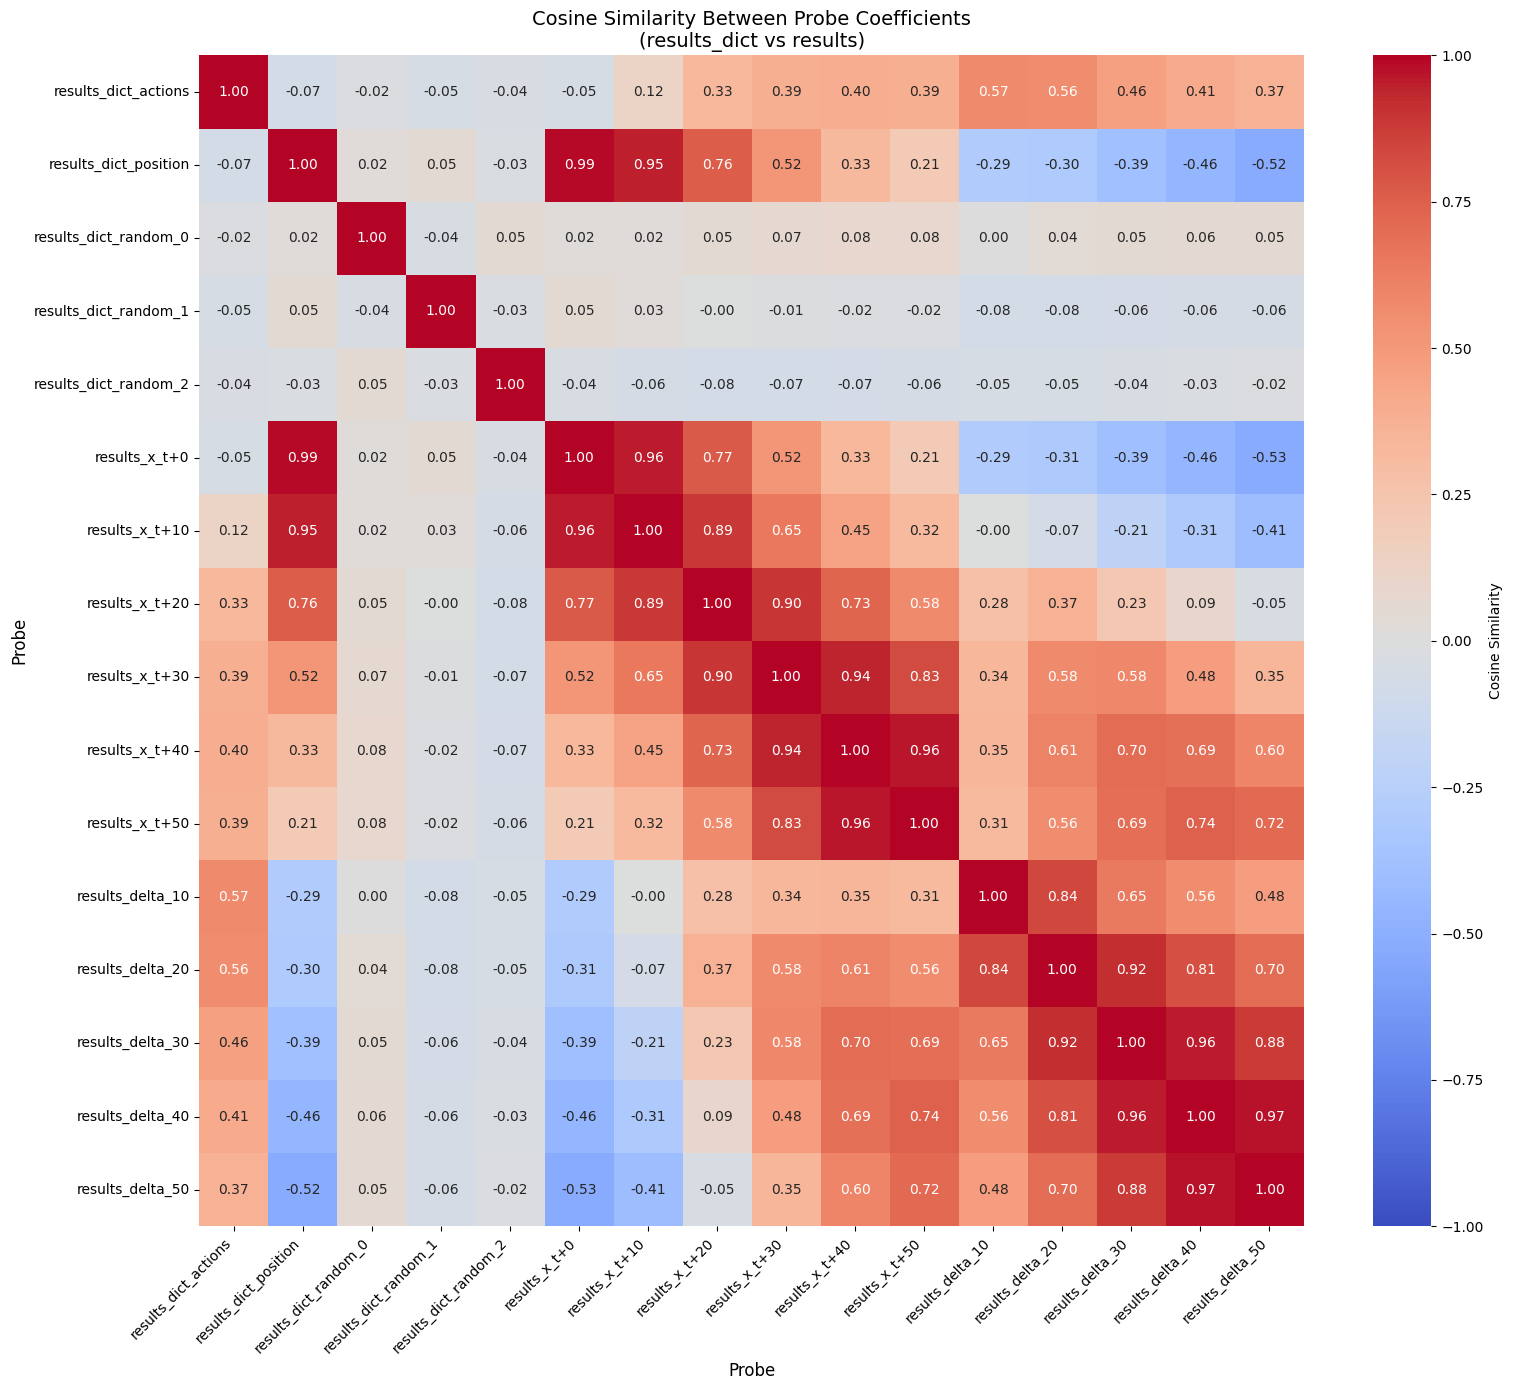

In [ ]:
# Compute cosine similarity between coefficients from results_dict and results
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Extract coefficients from both dictionaries
coef_dict_1 = {}
for k, v in results_dict.items():
    if 'coef' in v:
        coef_dict_1[k] = v['coef'].squeeze()
coef_dict_2 = {}
for k, v in results.items():
    if 'coef' in v:
        coef_dict_2[k] = v['coef']

# Combine all coefficients
all_keys = list(coef_dict_1.keys()) + list(coef_dict_2.keys())
all_coefs = [coef_dict_1[k] for k in coef_dict_1.keys()
            ] + [coef_dict_2[k] for k in coef_dict_2.keys()]
coef_matrix = np.array(all_coefs)

# Compute cosine similarity
similarity_matrix = cosine_similarity(coef_matrix)

# Create labels with prefixes to distinguish sources
labels = [f"results_dict_{k}" for k in coef_dict_1.keys()
         ] + [f"results_{k}" for k in coef_dict_2.keys()]

# Plot large confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(similarity_matrix,
            annot=True,
            fmt='.2f',
            xticklabels=labels,
            yticklabels=labels,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            cbar_kws={'label': 'Cosine Similarity'})
plt.title(
    'Cosine Similarity Between Probe Coefficients\n(results_dict vs results)',
    fontsize=14)
plt.xlabel('Probe', fontsize=12)
plt.ylabel('Probe', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [47]:
# Save coefficients to file
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/25-12-15-control-position-cartpole-swingup-noncentered/w_lr_coefs_noncentered_lagged_delta.pkl',
        'wb') as f:
    pickle.dump(results, f)

print("Coefficients saved to lagged_delta_coefs.pkl")

Coefficients saved to lagged_delta_coefs.pkl
